In [5]:
#libraries
import h5py
import numpy as np
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
import random
import time
import matplotlib.pyplot as plt

In [6]:
client = QdrantClient(
    host="qdrant",
    port=6333
)

client.get_collections()


CollectionsResponse(collections=[CollectionDescription(name='collection1'), CollectionDescription(name='test_collection')])

In [10]:
def create_collection(collection_name):
    client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=128,
        distance=Distance.EUCLID
        )
    )
    return None

def insert_data(collection_name):
    # opening file
    with h5py.File('../datasets/sift-128-euclidean.hdf5', 'r') as h5f:
        for keys in list(h5f["train"]):
            client.upsert(
                collection_name=collection_name,
                points=[PointStruct(id=i,vector=v.tolist())
            for i, v, in enumerate(vectors)
                   ])
    return None

In [11]:
name = "collection1"

create_collection(name);
print("Collection created")

UnexpectedResponse: Unexpected Response: 409 (Conflict)
Raw response content:
b'{"status":{"error":"Wrong input: Collection `collection1` already exists!"},"time":0.000082248}'

In [12]:
# opening file
BATCH_MAX_SIZE = 1000

with h5py.File('../datasets/sift-128-euclidean.hdf5', 'r') as h5f:
    #for keys in list(h5f["train"]):
     #   print(keys)
    #print(h5f["train"].shape)
    #for key in h5f.keys():
        #obj = h5f[key]
        #print (key, obj[0])
    #print(h5f["train"][1])
    for batch_level in range(0, h5f["train"].shape[0], BATCH_MAX_SIZE):
        batch = h5f["train"][batch_level:batch_level + BATCH_MAX_SIZE]
        points=[PointStruct(id=batch_level+j, vector=vector.tolist())
                           for j, vector in enumerate(batch)]
        
        client.upsert(
            collection_name="collection1",
            points=points)
    print("added successfully")
    #client.upsert(
        #collection_name="collection1",
        #points=[PointStruct(id=i,vector=v.tolist())
    #for i, v, in enumerate(h5f["train"])
           #])
    
# try to insert 100 items at one time

added successfully


In [13]:
#testing data
with h5py.File('../datasets/sift-128-euclidean.hdf5', 'r') as h5f:
    query_vector = h5f["test"][0]

    results = client.query_points(
        collection_name="collection1",
        query=query_vector.tolist(),
        limit=10,
    )

print(results)


points=[ScoredPoint(id=932085, version=1934, score=232.87122, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=934876, version=1936, score=234.71472, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=561813, version=1563, score=243.98976, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=708177, version=1710, score=255.46037, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=706771, version=1708, score=256.31427, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=695756, version=1697, score=258.86288, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=435345, version=1437, score=261.24127, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=701258, version=1703, score=264.28015, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=455537, version=1457, score=267.2845, payload={}, vector=None, sh

In [14]:
with h5py.File('../datasets/sift-128-euclidean.hdf5', 'r') as h5f:
    print(h5f["neighbors"][0][:10])

[932085 934876 561813 708177 706771 695756 435345 701258 455537 872728]


In [16]:
#Pipeline test
recalls = []
latency = []
test_data = []
counter = 0
recall_total = 0
recall_answer = 0
with h5py.File('../datasets/sift-128-euclidean.hdf5', 'r') as h5f:
    for j in range(10000):
        query_vector = h5f["test"][j]
        results = (client.query_points(
            collection_name="collection1",
            query=query_vector.tolist(),
            limit=10,
        ))
        #match formats
        for i in h5f["neighbors"][j][:10]:
            recalls.append(i)
        for i in results.points:
            test_data.append(i.id)
    
    amount = list(set(test_data) - set(recalls))
    
    recall = (len(test_data) - len(amount))/ ( len(recalls))
    counter += 1
    recall_total += recall
    recall_answer = (recall_total / counter) * 100
    recalls = []
    test_data = []

print (f"Recall@10: {recall_answer}%")

Recall@10: 98.428%


In [27]:
#Latency
recalls = []
latency = []
test_data = []
counter = 0
recall_total = 0
recall_answer = 0
with h5py.File('../datasets/sift-128-euclidean.hdf5', 'r') as h5f:
    for j in range(10000):
        query_vector = h5f["test"][j]
        start = time.perf_counter()
        results = (client.query_points(
            collection_name="collection1",
            query=query_vector.tolist(),
            limit=10,
        ))
        end = time.perf_counter()
        #caluclate latency
        latency.append((end - start) * 1000)
        #match formats
        for i in h5f["neighbors"][j][:10]:
            recalls.append(i)
        for i in results.points:
            test_data.append(i.id)
    
    amount = list(set(test_data) - set(recalls))
    
    recall = (len(test_data) - len(amount))/ ( len(recalls))
    counter += 1
    recall_total += recall
    recall_answer = (recall_total / counter) * 100
    recalls = []
    test_data = []

print (f"Recall@10: {recall_answer}%")
print(f"Average latency: {np.mean(latency):.3f} ms")
print(f"Median latency: {np.median(latency):.3f} ms")
print(f"Minimum latency: {np.min(latency):.3f} ms")
print(f"Maximum latency: {np.max(latency):.3f} ms")
print(f"Standard deviation: {np.std(latency):.3f} ms")

Recall@10: 98.4%
Average latency: 1.683 ms
Median latency: 1.514 ms
Minimum latency: 1.253 ms
Maximum latency: 64.890 ms
Standard deviation: 0.800 ms


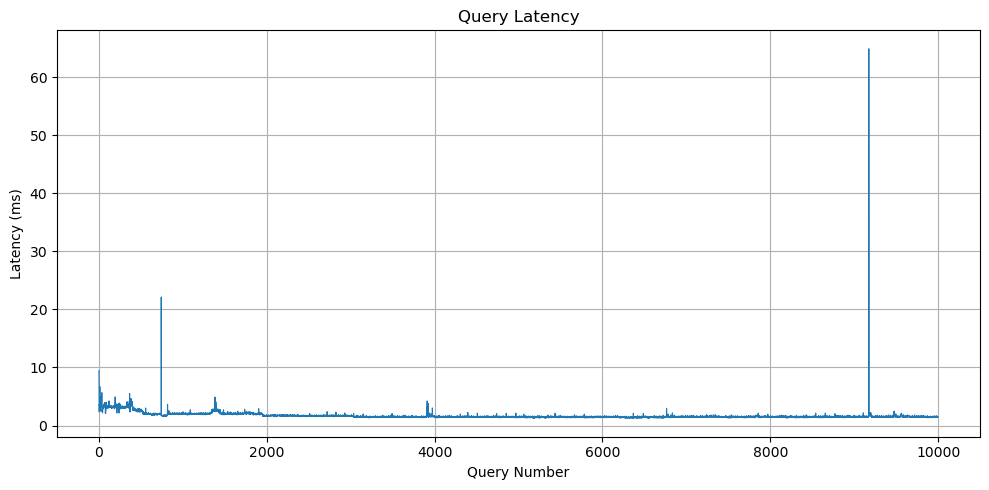

In [29]:
#display data
plt.figure(figsize=(10, 5))
plt.plot(latency, linewidth=0.8)
plt.title("Query Latency")
plt.xlabel("Query Number")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.tight_layout()
plt.show()